In [1]:
from sympy import symbols, simplify

# 1. Definir las variables
a, b, c, d, e = symbols('a b c d e')

a = (1 - a) / 2
b = (1 - b) / 2
c = (1 - c) / 2
d = (1 - d) / 2
e = (1 - e) / 2

expresion = (7*(a+b - (2*a*b)) + 5*(a+c - 2*a*c) + 1*(a+d - 2*a*d) + 10*(a+e - 2*a*e) + 
             9*(b+c - 2*b*c) + 4*(b+d - 2*b*d) + 3*(b+e - 2*b*e) + 
             7*(c+d - 2*c*d) + 8*(c+e - 2*c*e) + 6*(d+e - 2*d*e))


resultado_final = simplify(expresion)

print("Nueva expresión simplificada:")
print(resultado_final)


Nueva expresión simplificada:
-7*a*b/2 - 5*a*c/2 - a*d/2 - 5*a*e - 9*b*c/2 - 2*b*d - 3*b*e/2 - 7*c*d/2 - 4*c*e - 3*d*e + 30


In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

A = np.array([
    [0, 7, 5, 1, 10],  
    [7, 0, 9, 4, 3],  
    [5, 9, 0, 7, 8],
    [1, 4, 7, 0, 6] ,
    [10, 3, 8, 6, 0]  
])

print(A)


[[ 0  7  5  1 10]
 [ 7  0  9  4  3]
 [ 5  9  0  7  8]
 [ 1  4  7  0  6]
 [10  3  8  6  0]]


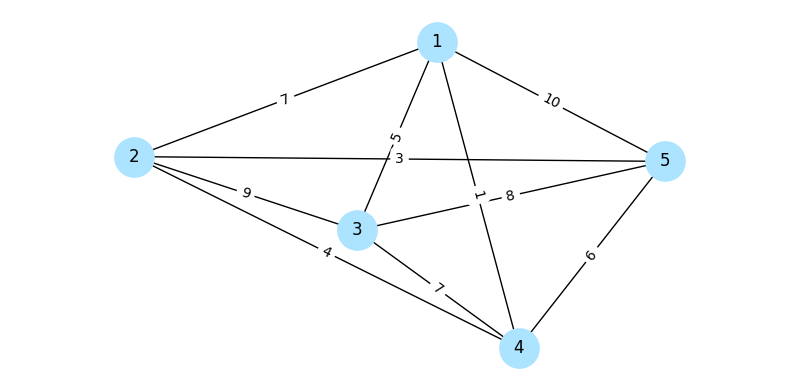

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))

# interpret diagonal of matrix as node attributes
node_labels = {n: A[n,n] + (n+1) for n in range(len(A))}
np.fill_diagonal(A, np.zeros(len(A)))

G1 = nx.Graph(A)
pos1 = nx.spring_layout(G1, seed=1)
nx.draw(G1, pos1, labels=node_labels, ax=ax, node_size = 800, node_color = "#ACE3FF")
edge_labels = nx.get_edge_attributes(G1,'weight')
nx.draw_networkx_edge_labels(G1,pos1,edge_labels=edge_labels, ax=ax)

ax.set_xlim([1.2*x for x in ax.get_xlim()])
plt.tight_layout()
plt.show()

0: ──RY(0.50)─╭●──RY(0.50)───────────────────────────────┤ ╭<𝓗>
1: ──RY(0.50)─╰X─╭●─────────RY(0.50)─────────────────────┤ ├<𝓗>
2: ──RY(0.50)────╰X────────╭●─────────RY(0.50)───────────┤ ├<𝓗>
3: ──RY(0.50)──────────────╰X────────╭●─────────RY(0.50)─┤ ├<𝓗>
4: ──RY(0.50)────────────────────────╰X─────────RY(0.50)─┤ ╰<𝓗>

Energía mínima:  -14.0000
Max-Cut = 30 - (-14.0000) = 44.0000
Parámetros finales: [1.3477, 3.1416, -0.0, 3.1416, 0.0, -0.0, 0.0, 3.1416, 0.0, 3.1416]


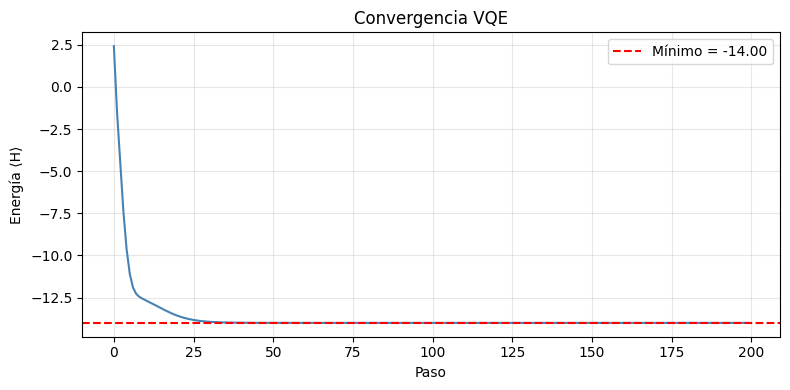

In [19]:
import pennylane as qml
from pennylane import numpy as np

coeffs = [7/2, 5/2, 1/2, 5, 9/2, 2, 3/2, 7/2, 4, 3]

obs = [
    qml.PauliZ(0) @ qml.PauliZ(1),
    qml.PauliZ(0) @ qml.PauliZ(2),
    qml.PauliZ(0) @ qml.PauliZ(3),
    qml.PauliZ(0) @ qml.PauliZ(4),
    qml.PauliZ(1) @ qml.PauliZ(2),
    qml.PauliZ(1) @ qml.PauliZ(3),
    qml.PauliZ(1) @ qml.PauliZ(4),
    qml.PauliZ(2) @ qml.PauliZ(3), 
    qml.PauliZ(2) @ qml.PauliZ(4), 
    qml.PauliZ(3) @ qml.PauliZ(4) ]

H = qml.Hamiltonian(coeffs, obs)

# ── Ansatz ──────────────────────────────────────────────────────
# 2 capas RY + CNOTs en cadena + CNOT cruzado D1-D5
n_qubits = 5
dev = qml.device("default.qubit", wires=n_qubits)

def ansatz(params, wires):
    for i, w in enumerate(wires):
        qml.RY(params[i], wires=w)           # Capa 1: rotaciones
    for i in range(len(wires) - 1):
        qml.CNOT(wires=[wires[i], wires[i+1]])  # Entrelazamiento en cadena
    for i, w in enumerate(wires):
        qml.RY(params[n_qubits + i], wires=w)  # Capa 2: rotaciones

# Dibujar el circuito
@qml.qnode(dev)
def circuit(params):
    ansatz(params, wires=range(n_qubits))
    return qml.expval(H)

print(qml.draw(circuit)(np.array([0.5] * 10)))

# ── Optimización ─────────────────────────────────────────────────
np.random.seed(42)
params = np.random.uniform(0, np.pi, 2 * n_qubits, requires_grad=True)

opt = qml.GradientDescentOptimizer(stepsize=0.1)
energies = []

for step in range(200):
    params, energy = opt.step_and_cost(circuit, params)
    energies.append(float(energy))

print(f"\nEnergía mínima:  {energies[-1]:.4f}")
print(f"Max-Cut = 30 - ({energies[-1]:.4f}) = {30 - energies[-1]:.4f}")
print(f"Parámetros finales: {[round(float(p), 4) for p in params]}")

# Curva de convergencia
plt.figure(figsize=(8, 4))
plt.plot(energies, color='steelblue')
plt.axhline(y=energies[-1], color='red', linestyle='--',
            label=f'Mínimo = {energies[-1]:.2f}')
plt.xlabel("Paso"); plt.ylabel("Energía ⟨H⟩")
plt.title("Convergencia VQE"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Estado óptimo:  |01001>
Max-Cut:        44
Canal A (xi=0): Drones [1, 3, 4]
Canal B (xi=1): Drones [2, 5]


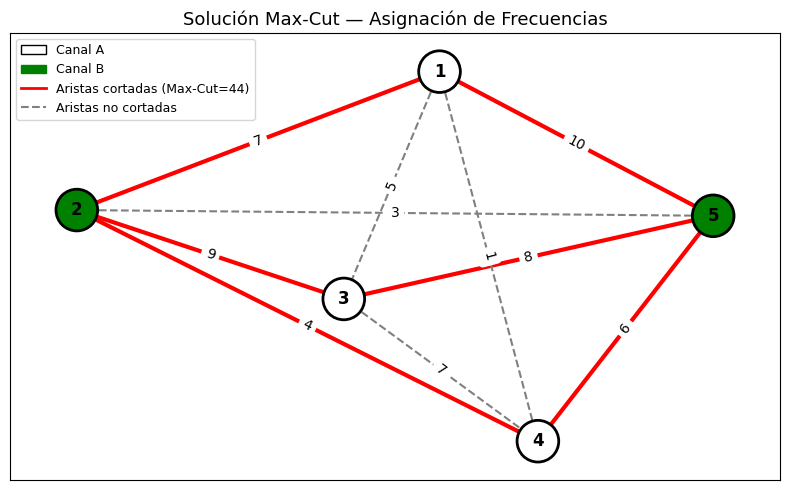

In [20]:
# ── Estado óptimo ────────────────────────────────────────────────
@qml.qnode(dev)
def probs_circuit(params):
    ansatz(params, wires=range(n_qubits))
    return qml.probs(wires=range(n_qubits))

probs = probs_circuit(params)
best  = int(np.argmax(probs))
state = format(best, '05b')       # ej. '10110'
x     = [int(b) for b in state]  # xi por dron

edges = [(0,1,7),(0,2,5),(0,3,1),(0,4,10),(1,2,9),
         (1,3,4),(1,4,3),(2,3,7),(2,4,8),(3,4,6)]
max_cut = sum(w for i,j,w in edges if x[i] != x[j])

print(f"Estado óptimo:  |{state}>")
print(f"Max-Cut:        {max_cut}")
print(f"Canal A (xi=0): Drones {[i+1 for i in range(5) if x[i]==0]}")
print(f"Canal B (xi=1): Drones {[i+1 for i in range(5) if x[i]==1]}")

# ── Grafo de solución ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

node_colors  = ['white' if x[i]==0 else 'green' for i in range(5)]
cut_edges    = [(i,j) for i,j,w in edges if x[i] != x[j]]
no_cut_edges = [(i,j) for i,j,w in edges if x[i] == x[j]]
edge_labels  = {(i,j): str(int(A[i][j])) for i,j,_ in edges}

nx.draw_networkx_nodes(G1, pos1, node_color=node_colors,
                       node_size=900, edgecolors='black', linewidths=2, ax=ax)
nx.draw_networkx_labels(G1, pos1, labels=node_labels, font_size=12,
                        font_weight='bold', ax=ax)
nx.draw_networkx_edges(G1, pos1, edgelist=cut_edges,
                       edge_color='red', width=3, ax=ax)
nx.draw_networkx_edges(G1, pos1, edgelist=no_cut_edges,
                       edge_color='gray', width=1.5, style='dashed', ax=ax)
nx.draw_networkx_edge_labels(G1, pos1, edge_labels=edge_labels, ax=ax)

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
ax.legend(handles=[
    Patch(facecolor='white', edgecolor='black', label='Canal A'),
    Patch(facecolor='green', edgecolor='green', label='Canal B'),
    Line2D([0],[0], color='red',  linewidth=2, label=f'Aristas cortadas (Max-Cut={max_cut})'),
    Line2D([0],[0], color='gray', linewidth=1.5, linestyle='--', label='Aristas no cortadas'),
], loc='upper left', fontsize=9)
ax.set_title("Solución Max-Cut — Asignación de Frecuencias", fontsize=13)
plt.tight_layout()
plt.show()